# Question 3: Insights and Use Cases

## Assignment
> On insights and use cases:
> - What first impressions do you get from this data?
> - Name three use cases for this dataset (assume you might also combine it with other public or Adevinta datasets).






In [14]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import display

helper_dir = Path.cwd()
if not (helper_dir / "functions.py").exists():
    helper_dir = Path.cwd() / "assignments" / "data_analyst"
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

import functions as helpers

helpers = importlib.reload(helpers)

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 80)
helpers.plt.style.use("seaborn-v0_8-whitegrid")


In [15]:
raw_data = helpers.read_ab_test_data(helpers.DATA_PATH)
insight_data = helpers.prepare_insight_data(raw_data)


## 1. First Impressions

The first impression is that this is a lead-interest dataset, not a complete sales dataset. That makes it useful for demand sensing and listing optimization, while also setting clear limits on what can be claimed from it.






### 1.1 Marketplace Funnel Shape

The dataset is strongest around buyer interest in live ads. It measures whether an ad generated leads, but it does not show the full marketplace funnel from search exposure to sale.






What the dataset covers:

- **Ad/listing attributes:** useful for listing optimization and descriptive lead analysis.
- **Vehicle attributes:** useful for segmenting demand by car type, though not enough to estimate final value.
- **Lead outcomes:** a good proxy for buyer interest, but not guaranteed conversion.
- **Experiment group assignment:** useful for q2, but not the main focus of q3.

What it does not cover:

- Search impressions or ranking position.
- Seller history and seller quality.
- Buyer identity or buyer journey.
- Final sale, sale price, revenue, margin, or lead quality.

This means the dataset is strong for understanding lead generation, but it needs additional funnel and commercial data before making ROI or transaction-success claims.






### 1.2 Seller-Level Opportunity

The current car-ad dataset is ad-level only: it has `src_ad_id`, but no seller or account identifier. That means we cannot aggregate lead performance by seller, identify SMB sellers, or directly target sellers from this dataset alone.

A valuable extension would be to join this car-ad dataset to a seller/account dataset. With a seller ID, Marktplaats could identify SMB sellers with patterns such as:

- many active car ads but low lead performance;
- many stale listings that may need renewal, pricing, or visibility support;
- strong organic lead potential but low usage of premium products;
- high-volume sellers in high-demand vehicle segments.

Business opportunity: use the combined view to single out SMB sellers who are likely to benefit from premium services, then offer targeted visibility products, bundles, or listing-quality recommendations.






<a id="insight-lead-channel-mix"></a>
### 1.3 Lead Channel Mix

The four lead fields may represent different buyer intent. A website click, phone click, bid, and seller question are all leads, but they probably do not have the same commercial meaning.







,Channel,Rows With Event,Ads With Event Share,Avg Events/Ad,Lead Event Share
3,Web Clicks,"97,931",0.535,2.739,0.514
2,Questions,"60,485",0.330,0.991,0.186
0,Tel Clicks,"57,429",0.314,0.917,0.172
1,Bids,"30,908",0.169,0.678,0.127


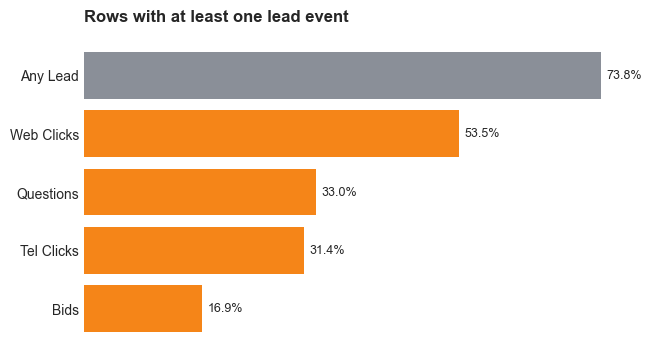

In [16]:
channel_mix = helpers.lead_channel_mix(insight_data)

display(helpers.style_table(channel_mix))
helpers.plot_lead_channel_coverage(insight_data)
helpers.plt.show()


This is useful beyond q2 because channel mix can shape product decisions. If channels behave differently, a single `has_any_lead` KPI is good for a headline view but not enough for understanding lead quality or seller value.






<a id="insight-channel-mix-by-price"></a>
#### 1.3.1 Channel Mix by Price Band

The channel mix is also different by segment. Looking at channel share by price band helps show whether different car-price segments attract different types of buyer interaction.






,Price Band,Tel Clicks,Bids,Questions,Web Clicks
0,0-25k,0.220,0.160,0.225,0.395
1,25k-60k,0.162,0.122,0.182,0.534
2,60k-120k,0.113,0.096,0.145,0.646
3,120k+,0.087,0.057,0.099,0.757


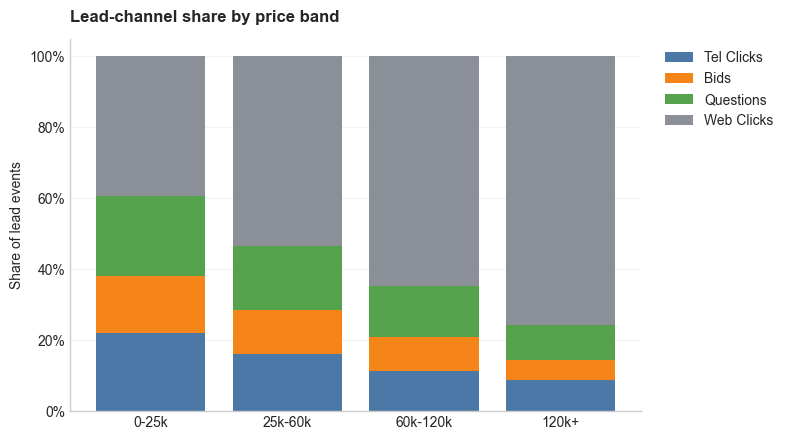

In [17]:
channel_share_by_price = helpers.lead_channel_mix_by_segment(insight_data, "price_band")

display(helpers.style_table(channel_share_by_price.reset_index()))
helpers.plot_lead_channel_mix_by_segment(channel_share_by_price, "Lead-channel share by price band")
helpers.plt.show()



<a id="insight-skew-concentration"></a>
### 1.4 Skew and Concentration

Lead generation is likely concentrated: many ads get some interest, while a smaller group receives a large number of total leads. That matters because averages can overstate the typical seller experience.







,Metric,Value
0,Ads With At Least One Lead,0.738
1,Median Total Leads,2
2,P90 Total Leads,14
3,P99 Total Leads,40
4,Lead Events From Top-Decile Ads,0.487


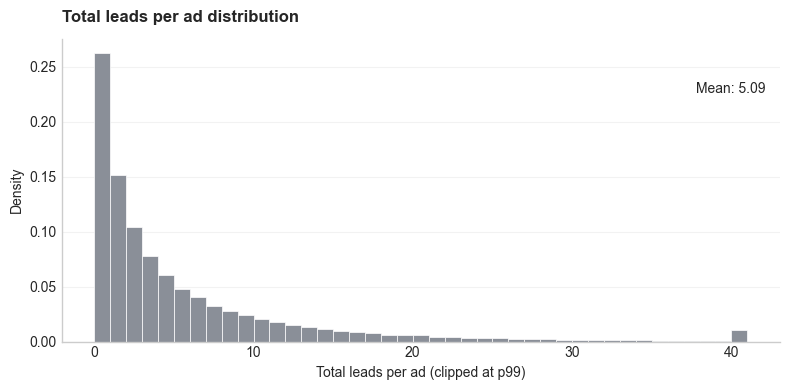

In [18]:
display(helpers.style_table(helpers.lead_concentration_summary(insight_data)))
helpers.plot_total_leads_distribution(insight_data.loc[insight_data["group"].isin(["A", "B"])])
helpers.plt.show()


- Lead volume is highly skewed: many ads receive few leads, while a small group receives many.
- Business implication: use median, percentile, and concentration views alongside averages.
- This helps separate typical seller experience from high-performing outliers.






<a id="insight-cumulative-lead-concentration"></a>
#### 1.4.1 Cumulative Lead Concentration

A cumulative lead-share curve makes the skew visible: if the curve rises quickly, a small share of ads accounts for a large share of all lead events.






,Top Ad Share,Ads,Lead Event Share
0,0.010,"1,830",0.117
1,0.050,"9,153",0.318
2,0.100,"18,306",0.474
3,0.200,"36,612",0.675


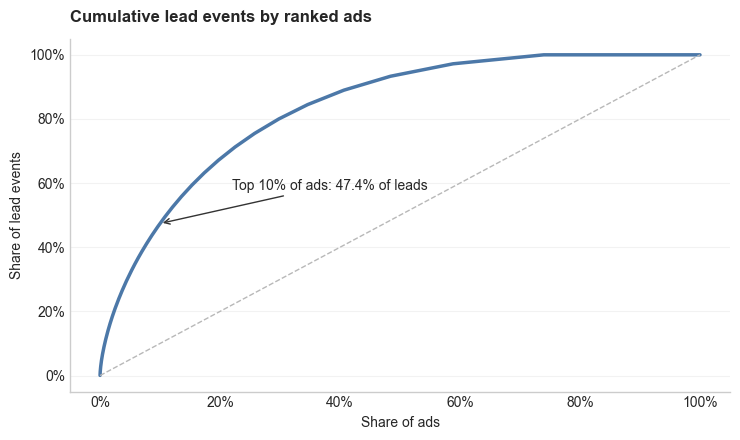

In [19]:
lead_rank, lead_share_cutoffs = helpers.lead_concentration_curve(insight_data)

display(helpers.style_table(lead_share_cutoffs))
helpers.plot_cumulative_lead_share(lead_rank, lead_share_cutoffs)
helpers.plt.show()



<a id="insight-listing-quality"></a>
### 1.5 Listing Quality Signals

Some fields describe how the ad is presented rather than what the car is. These are interesting because sellers or Marktplaats can potentially influence them.







,Photo Count Band,Ads,Lead Rate,Avg Leads/Ad,Median Days Live,Median Price,Ad Share
0,0-5,"8,630",0.797,8.092,31.000,"18,500.000",0.047
1,6-12,"61,208",0.816,6.968,31.000,"29,000.000",0.334
2,13-20,"57,750",0.730,4.934,31.000,"59,950.000",0.315
3,21+,"55,474",0.650,3.488,31.000,"117,450.000",0.303


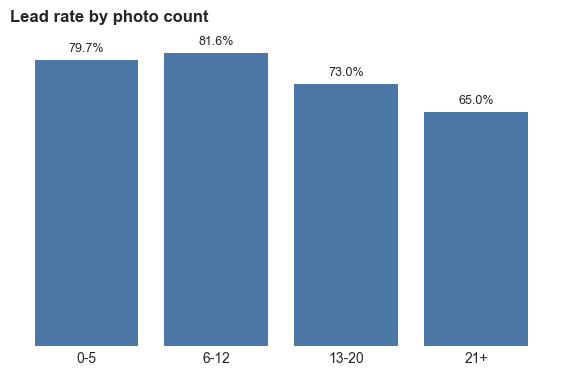

In [20]:
listing_quality = helpers.listing_quality_summary(insight_data)

display(helpers.style_table(listing_quality))
helpers.plot_photo_count_lead_rate(listing_quality)
helpers.plt.show()


Photo count is especially practical: unlike brand, model, or mileage, it is a seller action. If the pattern is strong enough after controlling for car type and price, it could become seller guidance or an automated listing-quality recommendation.






<a id="insight-vehicle-demand-patterns"></a>
### 1.6 Vehicle Attribute Demand Patterns

Vehicle fields are useful for understanding demand. They may not be directly changeable by sellers, but they help marketplace teams understand which segments attract more interest.







In [21]:
for segment_column in ["price_band", "km_band", "car_age_band"]:
    display(helpers.style_table(helpers.segment_insight_summary(insight_data, segment_column)))


,Price Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Ad Share
0,0-25k,"52,340",0.885,8.689,"11,500.000",11.000,0.286
1,25k-60k,"42,250",0.799,5.815,"39,990.000",14.000,0.231
2,60k-120k,"43,290",0.664,3.524,"87,450.000",18.000,0.236
3,120k+,"45,175",0.580,2.694,"184,450.000",22.000,0.247


,Mileage Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Ad Share
3,200k+,"45,272",0.860,7.167,"22,500.000",12.000,0.247
2,150k-200k,"35,863",0.825,6.583,"39,450.000",14.000,0.196
1,75k-150k,"56,374",0.748,5.117,"69,500.000",16.000,0.308
0,0-75k,"44,149",0.524,2.525,"139,000.000",20.000,0.241


,Car Age Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Ad Share
3,13+,"50,442",0.877,8.113,"14,500.000",11.000,0.276
2,8-12,"52,457",0.815,6.184,"44,950.000",14.000,0.287
1,4-7,"45,914",0.695,3.941,"97,500.000",18.000,0.251
0,0-3,"34,249",0.470,1.757,"169,950.000",22.000,0.187


In [22]:
body_type_summary = helpers.segment_insight_summary(insight_data, "carrosserie", min_ads=1000).head(10)
brand_summary = helpers.segment_insight_summary(insight_data, "brand", min_ads=1000).head(10)

display(helpers.style_table(body_type_summary))
display(helpers.style_table(brand_summary))


,Body Type,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Ad Share
1,Coup,"2,913",0.863,7.863,"89,500.000",17.000,0.016
5,Sedan (2/4-deurs),"15,472",0.841,7.035,"59,500.000",16.000,0.085
4,Overige carrosserie n,"2,494",0.769,5.712,"34,250.000",12.000,0.014
0,Cabriolet,"5,290",0.759,4.677,"69,900.000",17.000,0.029
6,Stationwagon,"29,233",0.742,4.709,"69,500.000",17.000,0.160
7,Terreinwagen,"10,128",0.729,4.649,"169,400.000",21.000,0.055
2,Hatchback (3/5-deurs),"79,944",0.719,5.614,"49,500.000",14.000,0.437
3,MPV,"19,737",0.692,3.879,"49,990.000",16.000,0.108


,Brand,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Ad Share
12,AUDI,"7,062",0.845,6.658,"122,475.000",19.000,0.039
37,DAEWOO,"1,070",0.829,7.456,"9,995.000",10.000,0.006
40,DAIHATSU,"1,052",0.825,6.743,"19,500.000",12.000,0.006
3,ALFA ROMEO,"1,577",0.824,6.674,"44,950.000",15.000,0.009
187,VOLKSWAGEN,"22,148",0.803,6.862,"69,000.000",15.000,0.121
20,BMW,"9,259",0.801,6.919,"119,900.000",20.000,0.051
123,MERCEDES,"7,809",0.796,6.481,"124,500.000",18.000,0.043
165,SEAT,"4,906",0.794,5.771,"47,125.000",14.000,0.027
120,MAZDA,"2,398",0.784,5.169,"33,675.000",14.000,0.013
31,CHEVROLET,"1,513",0.767,5.743,"38,500.000",14.000,0.008


These segment views were too exploratory for the q2 A/B story, but they fit q3 well. They can support inventory planning, merchandising, seller education, and commercial targeting.






### 1.7 Time and Listing Lifecycle Signals

The time fields can add a useful lifecycle view: `ad_start_dt` tells us when ads started, while `days_live` approximates how long listings have been active. This can support seller advice and promotion timing, but there is an important caveat: all ad start dates in this file are in November 2016, so this is not enough for seasonality or long-term trend analysis.






In [23]:
display(helpers.style_table(helpers.time_scope_summary(insight_data)))


,Metric,Value
0,Earliest Ad Start,2016-11-01
1,Latest Ad Start,2016-11-30
2,Days Live Median,31
3,Days Live P90,31
4,Days Live Max,134


<a id="insight-ad-lifecycle"></a>
#### 1.7.1 Ad Lifecycle

A first lifecycle question is whether lead outcomes differ by how long an ad has been live. Older ads naturally have had more time to collect leads, so this is descriptive rather than causal.







,Days Live Band,Ads,Lead Rate,Avg Leads/Ad,Median Leads/Ad,Median Price,Median Photos,Ad Share
0,0-3,"14,771",0.713,5.486,3.000,"29,990.000",12.000,0.081
1,4-7,"14,766",0.798,7.916,4.000,"36,500.000",14.000,0.081
2,8-14,"16,583",0.817,7.199,4.000,"39,990.000",15.000,0.091
3,15-31,"127,195",0.709,4.483,2.000,"69,500.000",16.000,0.695
4,31+,"9,747",0.928,8.951,6.000,"37,500.000",11.000,0.053


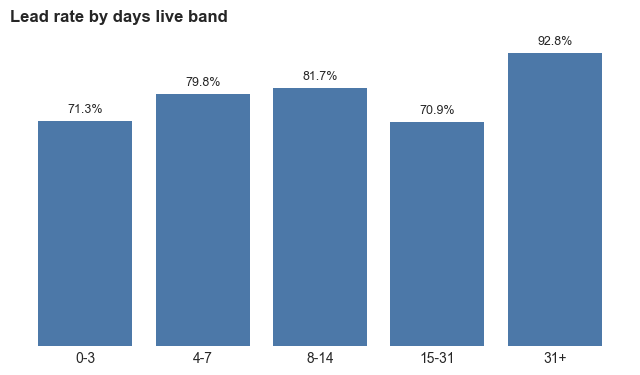

In [24]:
lifecycle_summary = helpers.lifecycle_summary(insight_data)

display(helpers.style_table(lifecycle_summary))
helpers.plot_lifecycle_lead_rate(lifecycle_summary)
helpers.plt.show()


#### 1.7.2 Start Day of Week

The start date can also be used to compare weekday posting patterns. If some start days consistently perform better, this could become seller guidance. For now, it should be read as an exploratory pattern because weekday differences may reflect inventory mix or seller behavior rather than timing alone.






,Start Weekday,Ads,Lead Rate,Avg Leads/Ad,Median Days Live,Median Price,Ad Share
0,Monday,"27,766",0.699,4.637,31.000,"65,000.000",0.152
1,Tuesday,"33,284",0.728,5.025,31.000,"59,900.000",0.182
2,Wednesday,"28,676",0.740,5.254,31.000,"55,000.000",0.157
3,Thursday,"28,054",0.739,5.832,31.000,"59,500.000",0.153
4,Friday,"29,752",0.751,5.457,31.000,"57,500.000",0.163
5,Saturday,"22,929",0.765,5.782,31.000,"54,500.000",0.125
6,Sunday,"12,601",0.759,5.519,31.000,"60,000.000",0.069


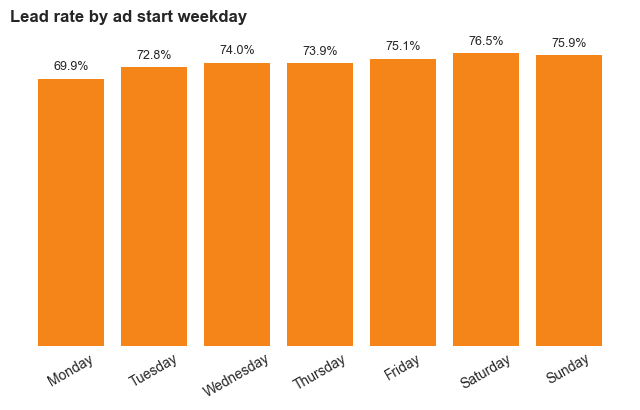

In [25]:
weekday_summary = helpers.weekday_summary(insight_data)

display(helpers.style_table(weekday_summary))
helpers.plot_weekday_lead_rate(weekday_summary)
helpers.plt.show()


<a id="insight-fresh-stale"></a>
#### 1.7.3 Fresh vs Stale Listings

A practical business lens is to classify ads as fresh, mid-life, or stale. This helps identify where product nudges might be useful: fresh listings need early momentum, while older low-performing listings may need price, photo, or promotion advice.







In [26]:
fresh_stale_summary = helpers.fresh_stale_summary(insight_data)

display(helpers.style_table(fresh_stale_summary))


,Lifecycle Stage,Ads,Lead Rate,Avg Leads/Ad,Median Leads/Ad,Median Price,Median Photos,Median Mileage,Ad Share
0,Fresh: 0-7 days,"29,537",0.755,6.701,3.000,"33,500.000",13.000,"155,151.000",0.161
1,Mid-life: 8-31 days,"143,778",0.721,4.796,2.000,"66,900.000",16.000,"132,728.000",0.785
2,Stale: 31+ days,"9,747",0.928,8.951,6.000,"37,500.000",11.000,"169,399.500",0.053


#### 1.7.4 Promotion Timing

The lifecycle view can become a product use case: trigger listing advice or paid promotion offers when an ad has been live long enough to judge early performance, but before the seller gives up or the listing becomes stale.






Potential promotion-timing triggers:

- **Fresh listing with weak early leads:** suggest more photos, a stronger description, or a price check after the first few days.
- **Mid-life listing with below-segment lead rate:** recommend renewal, homepage placement, or a targeted visibility boost.
- **Stale listing with low total leads:** prompt a price adjustment, content refresh, or de-list/repost guidance.
- **High-potential listing with strong early leads:** offer premium placement while demand is already visible.

Before using this in production, I would want impressions, search rank, comparable listings, seller edit history, paid exposure history, lead quality, conversion rate, and paid-product incrementality.






### 1.8 Dataset Limitations

The dataset is useful, but the missing pieces matter. These limitations also point directly to useful joins with other public or Adevinta datasets.






Main limitations and useful joins:

- **No final sale outcome:** add transaction data, final sale price, and listing close reason.
- **No buyer journey:** add search logs, clickstream, saved ads, and buyer cohorts.
- **No seller history:** add seller tenure, response speed, ratings, and subscription/product history.
- **No search exposure or ranking data:** add impressions, search rank, recommendation placement, and paid exposure.
- **No lead quality or duplicate-lead flag:** add lead follow-up, seller response, conversion, and spam/duplicate indicators.
- **Limited causal interpretation outside q2:** add experiment metadata, exposure logs, or stronger modelling controls.






<a id="insight-ad-characteristics-leads"></a>
### 1.9 Which Ad Characteristics Relate to Leads?

These comparisons are descriptive, not causal. They show how ads with at least one lead differ from ads without leads. This is useful for identifying candidate drivers to investigate more rigorously later.







In [27]:
lead_profile = helpers.lead_profile_summary(insight_data)

display(helpers.style_table(lead_profile))


has_any_lead,Dimension,No-Lead Median,Lead Median,Lead vs No-Lead Difference,% Difference vs No Lead
0,Price,"99,000.000","46,450.000","-52,550.000",-0.531
1,Mileage,"88,921.000","152,759.000","63,838.000",0.718
2,Car Age,5.000,10.000,5.000,1.000
3,Photos,18.000,14.000,-4.000,-0.222
4,Days Live,31.000,31.000,0.000,0.000
5,Power,75.000,77.000,2.000,0.027


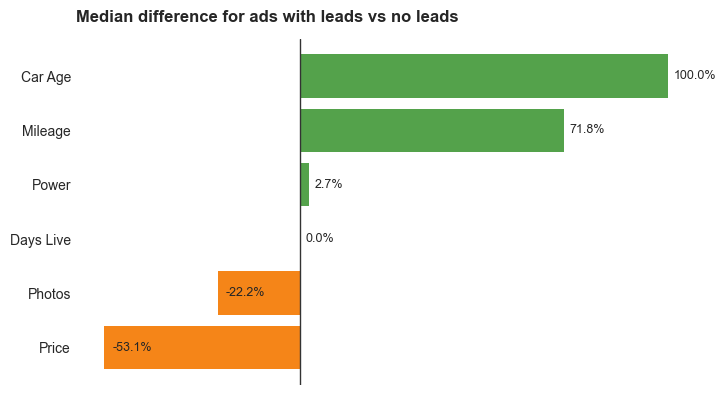

In [28]:
helpers.plot_lead_profile_differences(lead_profile)
helpers.plt.show()


## 2. Use Cases

The strongest use cases are the ones that turn the lead patterns into seller, commercial, or platform actions. I would keep seller listing optimization as the primary use case, then add commercial targeting and lead-channel strategy as supporting use cases.






### 2.1 Seller Listing Optimization

Use the data to estimate which listing choices and car attributes are associated with lead generation, then give sellers concrete guidance on listing quality, pricing context, and promotion timing.

The useful insight is not simply that one field drives leads. Ads with leads have a different listing profile: they are cheaper, older, and higher-mileage on the median, while the photo-count relationship is clearly mixed with vehicle segment and price. This supports seller guidance that should compare an ad to similar cars, not to the marketplace average.

- **Evidence callback:** see [listing quality signals](#insight-listing-quality), [vehicle attribute demand patterns](#insight-vehicle-demand-patterns), and [ad characteristics related to leads](#insight-ad-characteristics-leads).
- **Uses from this dataset:** `photo_cnt`, `price`, `kmstand`, `bouwjaar` / car age, `days_live`, `brand`, `model`, `carrosserie`, and lead outcomes such as `has_any_lead` and `total_leads`.
- **Useful merges:** seller/account data, listing edit history, image quality scores, comparable listings, local competition, final sale outcome, and final sale price.






### 2.2 Commercial Product Targeting

Use the car-ad data plus seller/account data to target paid visibility, lead-boosting products, or seller bundles toward sellers where incremental exposure is most likely to create value.

The commercial opportunity comes from two signals. First, lead volume is concentrated: a small set of ads captures a large share of all lead events. Second, the Q2 experiment showed that product changes can move lead rate. Together, these suggest paid products and seller offers should be targeted and measured by segment instead of pushed uniformly.

- **Evidence callback:** see [skew and concentration](#insight-skew-concentration), especially the [cumulative lead concentration](#insight-cumulative-lead-concentration) curve, plus [vehicle attribute demand patterns](#insight-vehicle-demand-patterns) and the Q2 notebook for the experiment lift.
- **Uses from this dataset:** lead rate, total lead volume, lead-channel mix, `days_live`, vehicle segment, price, mileage, car age, photo count, and stale or underperforming listing flags.
- **Useful merges:** seller ID, seller type, subscription status, paid-product purchase history, margins, churn risk, seller inventory size, lead quality, downstream conversion, and revenue.






### 2.3 Lead-Channel Strategy

Use the split between phone clicks, bids, seller questions, and website clicks to understand what kind of buyer interaction each listing attracts. This is useful because not every lead type has the same business value.

The dataset shows that channel mix is uneven. Web clicks dominate total lead events, while questions, phone clicks, and bids represent smaller but potentially higher-intent actions. That creates a clear next step: keep the channel split in reporting, then merge lead quality or conversion data before deciding which channels to optimize for.

- **Evidence callback:** see [lead channel mix](#insight-lead-channel-mix), especially [channel mix by price band](#insight-channel-mix-by-price), and [skew and concentration](#insight-skew-concentration).
- **Uses from this dataset:** `telclicks`, `bids`, `n_asq`, `webclicks`, `has_any_lead`, `total_leads`, and segment fields that show where different lead types are more common.
- **Useful merges:** lead-quality data such as seller response, duplicate leads, spam flags, buyer follow-up, buyer identity or cohort, and final conversion. Without this enrichment, the dataset can show channel volume but not which channels are most valuable.




